## Quantum Fourier Transform (QFT)

### Manual QFT (2-Qubit)

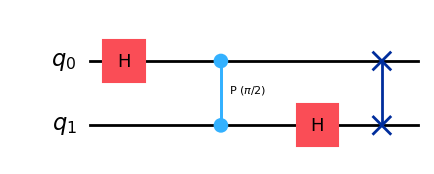

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

def qft_2_qubits():
    qc = QuantumCircuit(2)

    # Step 1: Hadamard on qubit 0
    qc.h(0)

    # Step 2: Controlled phase rotation
    qc.cp(3.141592653589793/2, 1, 0)  # π/2

    # Step 3: Hadamard on qubit 1
    qc.h(1)

    # Step 4: Swap qubits (bit reversal)
    qc.swap(0,1)

    return qc

qc = qft_2_qubits()
qc.draw('mpl')

In [2]:
qc_test = QuantumCircuit(2)
qc_test.x(1)  # Input |10>

qc_test.compose(qft_2_qubits(), inplace=True)

sv = Statevector.from_instruction(qc_test)
print(sv)

Statevector([ 5.000000e-01+0.j , -5.000000e-01+0.j ,  3.061617e-17+0.5j,
             -3.061617e-17-0.5j],
            dims=(2, 2))


## QFT for 3 Qubits

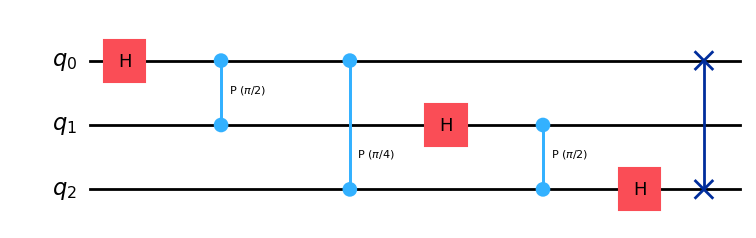

In [3]:
import numpy as np
from qiskit import QuantumCircuit

def qft(n):
    qc = QuantumCircuit(n)

    for j in range(n):
        qc.h(j)
        for k in range(j+1, n):
            qc.cp(np.pi / (2**(k-j)), k, j)

    # Swap for bit reversal
    for i in range(n//2):
        qc.swap(i, n-i-1)

    return qc

qc3 = qft(3)
qc3.draw('mpl')

## Inverse QFT Verification

In [4]:
def inverse_qft(n):
    qc = QuantumCircuit(n)

    # Reverse swaps
    for i in range(n//2):
        qc.swap(i, n-i-1)

    for j in reversed(range(n)):
        for k in reversed(range(j+1, n)):
            qc.cp(-np.pi / (2**(k-j)), k, j)
        qc.h(j)

    return qc

In [5]:
from qiskit.quantum_info import Statevector

qc_test = QuantumCircuit(3)

# Prepare arbitrary state
qc_test.x(0)
qc_test.h(1)

# Apply QFT
qc_test.compose(qft(3), inplace=True)

# Apply inverse QFT
qc_test.compose(inverse_qft(3), inplace=True)

sv = Statevector.from_instruction(qc_test)
print(sv)

Statevector([-9.52420783e-18-8.34944624e-18j,
              7.07106781e-01+8.34944624e-18j,
             -9.52420783e-18-1.32994552e-17j,
              7.07106781e-01+1.32994552e-17j,
              3.36731597e-18+2.34892061e-34j,
              3.36731597e-18-3.09843189e-34j,
              3.36731597e-18+4.76210391e-18j,
              3.36731597e-18-4.76210391e-18j],
            dims=(2, 2, 2))


{'101': 109, '100': 128, '110': 138, '001': 129, '111': 135, '011': 136, '000': 118, '010': 131}


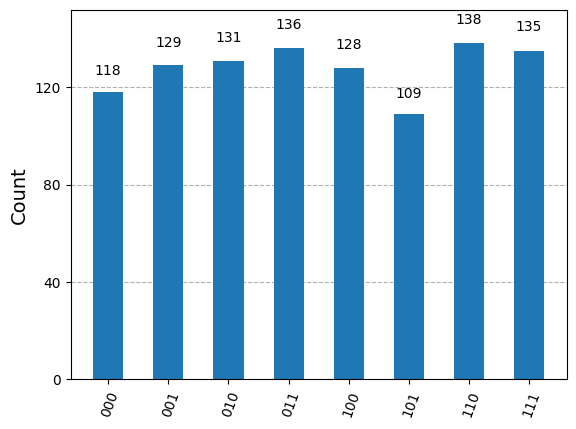

In [7]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

qc_meas = QuantumCircuit(3,3)

qc_meas.x(1)

qc_meas.compose(qft(3), inplace=True)

qc_meas.measure(range(3), range(3))

sim = AerSimulator()
result = sim.run(qc_meas, shots=1024).result()
counts = result.get_counts()

print(counts)
plot_histogram(counts)
#plt.show()